RDD on CN data

# Data sources

From x.com we download the raw data (including notes-00000.tsv)

On HPC we apply the scoring algorithsms, generating output in parquet format

We preprocess and merge these files using

    preprocess_dates.py
    merge_ratings_with_notes.py

# Environment

see requirements.txt or communitynotes2025-05-09.yml

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
import calendar
from sklearn import linear_model
import statsmodels.api as sm
import statsmodels.formula.api as smf
import fastparquet



# TODO

add data prep instructions

## RDD

**Research question(s)**: Is it a problem that such a low proportion of notes are rated as helpful ? Restated, at the individual level: Does having a note rated as helpful encourage future contributions, and conversely, does not having a note rated as helpful discourage future contributions. Our unit of analysis is the individuals in the CN system: how are they affected by what happens to their notes?

**Design**: regression discontinuity, comparing notes around threshold for being rated helpful

**Candidate set**: all first-time note authors (yes, most notes might be authored by a minority of repeat authors, but these people are already committed to CN and/or are the people least likely to be influenced by note success, *and* I think the effect on people who have just jointed CN is the one we are most interested in). We will look at the first note of first time note authors only.

(option: we could just look at the first note of 2024, rather than of all time)

**Outcome measure**: does the first time note author go on to author another note? (ie in the rest of 2024).

**Predictors**: there is this issue of notes flip-flopping between helpful and unhelpful. After two weeks a note's status is fixed, and a note author receives notifications each time the note status changes. To create a tractable analysis, consider these two simplifications

A. Final outcome: either Helpful (1) or Unhelpful (0), ignoring all prior status history. We compare notes whose final score was just above and below threshold for this. Call this H

B. Notification occurrence : note author received a notification that the note was rated helpful (1), or never did (0). We compare notes whose maximum all time score was just above or below threshold for this. Call this N

Note that the two predictors define two, distinct, subsets of the candidates (ie you can't just throw both predictors into the same regression, since authors who have a relevant score for H may not have a value for N, and vice versa)

In [2]:
# First let's inmport the data anbd count how many notes we have

rated = pd.read_parquet('/Users/arjmandilari/Documents/Tom Stafford/cn/community_notes/data2025post/' + 'rated_notes_compact.parquet', engine='auto')

len(rated) #1,946,619 for 2025 data


1946619

In [3]:
rated.columns

Index(['noteId', 'finalRatingStatus', 'classification', 'createdAtMillis',
       'createdAt', 'createdAtYear', 'createdAtMonth', 'numRatings',
       'noteAuthorParticipantId', 'tweetId', 'firstNonNMRStatus',
       'currentStatus', 'mostRecentNonNMRStatus', 'lockedStatus',
       'coreNoteIntercept', 'coreNoteFactor1', 'coreRatingStatus', 'decidedBy',
       'expansionNoteIntercept', 'expansionNoteFactor1',
       'expansionRatingStatus', 'coverageNoteIntercept', 'coverageNoteFactor1',
       'coverageRatingStatus', 'coreNoteInterceptMin', 'coreNoteInterceptMax',
       'expansionNoteInterceptMin', 'expansionNoteInterceptMax',
       'coverageNoteInterceptMin', 'coverageNoteInterceptMax',
       'groupNoteIntercept', 'groupNoteFactor1', 'groupRatingStatus',
       'groupNoteInterceptMax', 'groupNoteInterceptMin', 'modelingGroup',
       'summary', 'isMediaNote'],
      dtype='object')

In [4]:
# For RDD we need to remove the notes which don't have enough rating to be helpful
rated['rating_group'] = np.where(rated['numRatings'] >= 5,
                                        1, 0)


In [5]:
rated[rated['rating_group'] == 1]['decidedBy'].value_counts(normalize=True)

decidedBy
CoreModel (v1.1)                   0.836745
ExpansionModel (v1.1)              0.070361
ScoringDriftGuard (v1.0)           0.047207
MultiGroupModel01 (v1.0)           0.030236
NmrDueToMinStableCrhTime (v1.0)    0.007534
ExpansionPlusModel (v1.1)          0.002571
GroupModel03 (v1.1)                0.001078
TopicModel01 (v1.0)                0.000689
GroupModel01 (v1.1)                0.000661
GroupModel13 (v1.1)                0.000651
GroupModel09 (v1.1)                0.000541
TopicModel02 (v1.0)                0.000523
GroupModel06 (v1.1)                0.000517
GroupModel02 (v1.1)                0.000210
InsufficientExplanation (v1.0)     0.000117
GroupModel14 (v1.1)                0.000115
GroupModel11 (v1.1)                0.000099
GroupModel10 (v1.1)                0.000062
TopicModel03 (v1.0)                0.000031
GroupModel04 (v1.1)                0.000019
GroupModel07 (v1.1)                0.000014
GroupModel05 (v1.1)                0.000007
GroupModel12 (v1.1)   

From notes which have enough rating to change their status, more than 83% are from core model, and more than 7% from expansion model. So if we include these 2 models, we have covered more than 90% of the notes.

In [6]:
# Restricting our analysis to notes after 2024
rated_2024 = rated[(rated.createdAt >= pd.Timestamp(2024, 1, 1))]

# Find the first note written by each author, and if that author goes on to write another note
first_notes = rated.groupby('noteAuthorParticipantId')\
    [['createdAt', 'finalRatingStatus', 'numRatings', 'rating_group', 'decidedBy','coreNoteFactor1', 'coreNoteIntercept', 'coreNoteInterceptMax','expansionNoteFactor1', 'expansionNoteIntercept', 'expansionNoteInterceptMax', 'classification']]\
    .first().reset_index()
# Restricting our analysis to authors who joined in 2024 
first_notes = first_notes[(first_notes.createdAt >= pd.Timestamp(2024, 1, 1)) &
                          (first_notes.createdAt < pd.Timestamp(2025, 1, 1))]

have_another_note = rated_2024[rated_2024.groupby('noteAuthorParticipantId').cumcount() >= 2]\
    ['noteAuthorParticipantId'].to_list()
first_notes['if_written_again'] = first_notes['noteAuthorParticipantId'].isin(have_another_note)

# restrict our analysis to core, and expansion and expansionplus models
first_notes = first_notes[first_notes['decidedBy'].isin(['CoreModel (v1.1)', 'ExpansionModel (v1.1)'])]
# first_notes = first_notes[first_notes['decidedBy'].isin(['CoreModel (v1.1)'])]
# remove NNNs
first_notes = first_notes[first_notes['classification'] != 'NOT_MISLEADING']


In [7]:
cores = first_notes[first_notes['decidedBy'] == 'CoreModel (v1.1)']

In [8]:
cores[(cores['rating_group'] == 1) & (cores['coreNoteIntercept'] > .4) & (np.abs(cores['coreNoteFactor1']<.5))]['finalRatingStatus'].value_counts()

finalRatingStatus
CURRENTLY_RATED_HELPFUL    6942
NEEDS_MORE_RATINGS          791
Name: count, dtype: int64

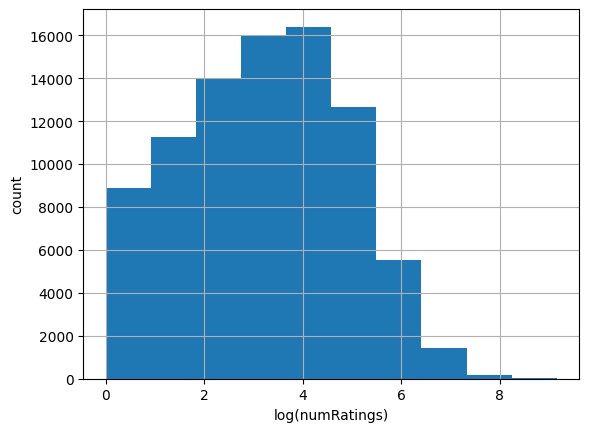

In [9]:
# Most notes have a small number of rating, a small number have very many ratinhgs
# This means the distribution of ratings is very skewed.
# We take the log of the number of ratings to make the distribution more normal


first_notes['log_numRatings']=np.log(first_notes['numRatings'])
# some don't even have 1 rating
first_notes[first_notes['numRatings'] > 0]['log_numRatings'].hist() #normal
plt.xlabel('log(numRatings)')
plt.ylabel('count')
plt.show()



Q. How many of the notes have equal current and max score?


In [10]:
first_notes[(first_notes['decidedBy'].isin(['CoreModel (v1.1)'])) & (first_notes['coreNoteIntercept'] == first_notes['coreNoteInterceptMax'])]

,noteAuthorParticipantId,createdAt,finalRatingStatus,numRatings,rating_group,decidedBy,coreNoteFactor1,coreNoteIntercept,coreNoteInterceptMax,expansionNoteFactor1,expansionNoteIntercept,expansionNoteInterceptMax,classification,if_written_again,log_numRatings


So, none of them have kept the max intercept!

In [11]:
first_notes['finalRatingStatus'].value_counts()

finalRatingStatus
NEEDS_MORE_RATINGS             74656
CURRENTLY_RATED_HELPFUL         8729
CURRENTLY_RATED_NOT_HELPFUL     2869
Name: count, dtype: int64

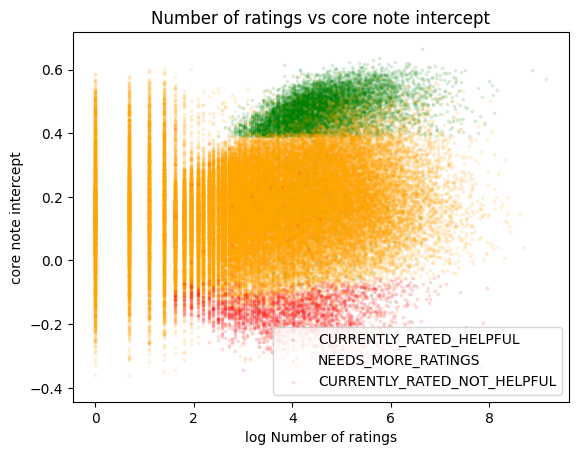

In [12]:
# Plotting log(numRatings) vs NoteInterceptMax, with colours according to Note final statuys (finalRatingStatus )  
plt.clf()
groups = ['CURRENTLY_RATED_HELPFUL','NEEDS_MORE_RATINGS','CURRENTLY_RATED_NOT_HELPFUL']
colours=['green','orange','red']

ms=3;alphaval=0.1;

# add intercept for all decidedBys
first_notes['intercept'] = np.where(
    first_notes["decidedBy"] == "CoreModel (v1.1)",
    first_notes["coreNoteIntercept"],
    first_notes["expansionNoteIntercept"]
)

for i in range(3):
    plt.scatter(first_notes[first_notes['finalRatingStatus']==groups[i]]['log_numRatings'], first_notes[first_notes['finalRatingStatus']==groups[i]]['coreNoteIntercept'], s = ms,alpha=alphaval,color=colours[i],label=groups[i])  
    # j+=1

plt.xlabel('log Number of ratings')
plt.ylabel('core note intercept')
plt.title('Number of ratings vs core note intercept')
plt.legend(loc=0)
plt.savefig('scatter_numRatings_coreNoteIntercept.png',dpi=120,bbox_inches='tight')
plt.show()

#TODO make the legend markers bigger and clearer

# Intepretation:

There is a discontinuity: although some notes labelled NEEDS_MORE_RATINGS have a score above 0.4, no notes with a score below 0.4 have a label CURERENTLY_RATED_HELPFUL

This establishes the logic required for our analaysis

# Now, the RDD

In [79]:
first_notes.head(20)

,noteAuthorParticipantId,createdAt,finalRatingStatus,numRatings,rating_group,decidedBy,coreNoteIntercept,coreNoteInterceptMax,expansionNoteIntercept,expansionNoteInterceptMax,classification,if_written_again,log_numRatings,intercept
9,000304B792000A2283133C9E2EBC94CC609C308CE68611...,2024-11-23 14:56:11.849,CURRENTLY_RATED_NOT_HELPFUL,9,1,CoreModel (v1.1),-0.185286,-0.082190,-0.181048,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,2.197225,-0.185286
14,00040B454C5517E81FD008193A19E3F27C2E9F1F09A356...,2024-08-02 13:29:20.660,CURRENTLY_RATED_HELPFUL,36,1,ExpansionModel (v1.1),NaN,NaN,0.456590,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,3.583519,0.456590
15,000415A1E3D1DA95BD626E1D938E4A9AFFB446D1A7D532...,2024-05-02 12:48:23.059,NEEDS_MORE_RATINGS,10,1,CoreModel (v1.1),0.002451,0.118490,0.046076,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,2.302585,0.002451
19,00055253971F408A7AB80D461A543E010EC67DFAF29C45...,2024-02-05 08:22:29.333,NEEDS_MORE_RATINGS,38,1,CoreModel (v1.1),0.181093,0.297216,0.165358,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,3.637586,0.181093
20,0005983E6E18862483AB372C5B61FEBC1F8A573E7701F9...,2024-01-21 10:46:25.047,NEEDS_MORE_RATINGS,3,0,CoreModel (v1.1),0.415720,0.419939,0.476264,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,1.098612,0.415720
22,0006F620D4B7B92610B8BEF2D60EDA22FDF292B2E6FD99...,2024-12-28 04:18:00.729,NEEDS_MORE_RATINGS,5,1,CoreModel (v1.1),0.023077,0.133474,0.016792,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,1.609438,0.023077
23,0006FACBF92B7C377BAF1F4ED81E8A077140A63B716C47...,2024-05-26 05:45:22.626,NEEDS_MORE_RATINGS,11,1,ExpansionModel (v1.1),NaN,NaN,0.356748,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,2.397895,0.356748
24,000780112CAEE3070B6E6958307E1080102F360E2DC348...,2024-12-04 15:47:47.521,NEEDS_MORE_RATINGS,11,1,CoreModel (v1.1),-0.007807,0.112248,0.111355,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,2.397895,-0.007807
26,0007FC9C45CFCA8A69FADA0270E80C452080CC9498019B...,2024-03-18 12:50:43.203,NEEDS_MORE_RATINGS,6,1,CoreModel (v1.1),0.049311,0.168563,0.047302,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,1.791759,0.049311
27,000890B506206C1EE8A8E990518BF2609F22316D506AD4...,2024-05-16 15:26:58.830,NEEDS_MORE_RATINGS,45,1,CoreModel (v1.1),-0.065649,0.018966,-0.094196,NaN,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,3.806662,-0.065649


In [104]:
# prepare the common vars for all models
# RDD 
cutoff = 0.4 #threshold at which a note is rated as helpful
bandwidth = 0.025 #window around cutoff
# keep only notes with enough rating
first_notes = first_notes[first_notes['rating_group'] == 1]

Now the models with all data:

In [106]:
# all notes
# most recent score

running_variable = np.where(
    first_notes["decidedBy"] == "CoreModel (v1.1)",
    first_notes["coreNoteIntercept"],
    first_notes["expansionNoteIntercept"])

# Treatment = 1 if running_variable >= cutoff, else 0
treatment = np.where(running_variable >= cutoff, 1, 0)

#
outcome_variable = first_notes['if_written_again'].astype(int) # y value, binary output

# we can restrict the analysis to a window (bandwidth) around the cutoff.

mask = (running_variable > cutoff - bandwidth)  & (running_variable < cutoff + bandwidth)

data = pd.DataFrame({
    'running_variable': running_variable[mask],
    'treatment': treatment[mask],
    'outcome_variable': outcome_variable[mask]
})

# Center the running variable at the cutoff for easier interpretation of the intercept
data['running_variable_centered'] = data['running_variable'] - cutoff
print("All data, current score")
print(f"\nNumber of treated units: {data['treatment'].sum()}")
print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# original
rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()

# The coefficient for 'treatment' is the estimated effect at the cutoff.
estimated_effect = rdd_model.params['treatment']
print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

print("I think we can intepret this as a % change the chance of authoring again if published")

p_value_treatment = rdd_model.pvalues['treatment']
t_statistic_treatment = rdd_model.tvalues['treatment']

# print out p value and t-statistic for treatment
print(f"\nP-value for treatment: {p_value_treatment:.4f}")
print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")



All data, current score

Number of treated units: 1613
Number of control units: 1576

Estimated Treatment Effect at the Cutoff: 0.0247
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.4705
T-statistic for treatment: 0.7217


In [107]:
# now with max score

running_variable_max = np.where(
    first_notes["decidedBy"] == "CoreModel (v1.1)",
    first_notes["coreNoteInterceptMax"],
    first_notes["expansionNoteInterceptMax"]
) # x value, continuous input

# Treatment = 1 if running_variable >= cutoff, else 0
treatment = np.where(running_variable_max >= cutoff, 1, 0)

#
outcome_variable = first_notes['if_written_again'].astype(int) # y value, binary output

# we can restrict the analysis to a window (bandwidth) around the cutoff.

mask = (running_variable_max > cutoff - bandwidth)  & (running_variable_max < cutoff + bandwidth)

data = pd.DataFrame({
    'running_variable': running_variable_max[mask],
    'treatment': treatment[mask],
    'outcome_variable': outcome_variable[mask]
})

# Center the running variable at the cutoff for easier interpretation of the intercept
data['running_variable_centered'] = data['running_variable'] - cutoff
print(f"\nAll data, max score")
print(f"\nNumber of treated units: {data['treatment'].sum()}")
print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# original
rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()

# The coefficient for 'treatment' is the estimated effect at the cutoff.
estimated_effect = rdd_model.params['treatment']
print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

print("I think we can intepret this as a % change the chance of authoring again if published")

p_value_treatment = rdd_model.pvalues['treatment']
t_statistic_treatment = rdd_model.tvalues['treatment']

# print out p value and t-statistic for treatment
print(f"\nP-value for treatment: {p_value_treatment:.4f}")
print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")


All data, max score

Number of treated units: 2116
Number of control units: 2734

Estimated Treatment Effect at the Cutoff: 0.0188
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.5171
T-statistic for treatment: 0.6479


Models with aligned notes (thier current score with locked status)

In [ ]:
# only aligned notes 

running_variable = np.where(
    first_notes["decidedBy"] == "CoreModel (v1.1)",
    first_notes["coreNoteIntercept"],
    first_notes["expansionNoteIntercept"]
) # x value, continuous input
first_notes['intercept'] = running_variable

# Treatment = 1 if running_variable >= cutoff, else 0
treatment = np.where(running_variable >= cutoff, 1, 0)
outcome_variable = first_notes['if_written_again'].astype(int)
# keep when intercept and locked status align & factor is less than .5
mask_alignment = (((first_notes["intercept"] > cutoff) & 
    (first_notes["finalRatingStatus"] == "CURRENTLY_RATED_HELPFUL") &
    (fir)) |
    ((first_notes["intercept"] < cutoff) & (first_notes["finalRatingStatus"] != "CURRENTLY_RATED_HELPFUL")))
mask = (running_variable > cutoff - bandwidth)  & (running_variable < cutoff + bandwidth)
data = pd.DataFrame({
    'running_variable': running_variable[mask & mask_alignment],
    'treatment': treatment[mask & mask_alignment],
    'outcome_variable': outcome_variable[mask & mask_alignment]
})

# Center the running variable at the cutoff for easier interpretation of the intercept
data['running_variable_centered'] = data['running_variable'] - cutoff
print(f"\nAligned data, current score")
print(f"\nNumber of treated units: {data['treatment'].sum()}")
print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# original
rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()
# The coefficient for 'treatment' is the estimated effect at the cutoff.
estimated_effect = rdd_model.params['treatment']
print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

print("I think we can intepret this as a % change the chance of authoring again if published")

p_value_treatment = rdd_model.pvalues['treatment']
t_statistic_treatment = rdd_model.tvalues['treatment']

# print out p value and t-statistic for treatment
print(f"\nP-value for treatment: {p_value_treatment:.4f}")
print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")


Aligned data, current score

Number of treated units: 1282
Number of control units: 1174

Estimated Treatment Effect at the Cutoff: 0.0534
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.2099
T-statistic for treatment: 1.2542


In [109]:
# only aligned notes with max score
running_variable_max = np.where(
    first_notes["decidedBy"] == "CoreModel (v1.1)",
    first_notes["coreNoteInterceptMax"],
    first_notes["expansionNoteInterceptMax"]
) # x value, continuous input

first_notes['intercept'] = running_variable_max
# keep when intercept and locked status align
# Treatment = 1 if running_variable >= cutoff, else 0
treatment = np.where(running_variable_max >= cutoff, 1, 0)
outcome_variable = first_notes['if_written_again'].astype(int)

mask_alignment = (((first_notes["intercept"] > cutoff) & (first_notes["finalRatingStatus"] == "CURRENTLY_RATED_HELPFUL")) |
    ((first_notes["intercept"] < cutoff) & (first_notes["finalRatingStatus"] != "CURRENTLY_RATED_HELPFUL")))
mask = (running_variable_max > cutoff - bandwidth)  & (running_variable_max < cutoff + bandwidth)
data = pd.DataFrame({
    'running_variable': running_variable_max[mask & mask_alignment],
    'treatment': treatment[mask & mask_alignment],
    'outcome_variable': outcome_variable[mask & mask_alignment]
})

# Center the running variable at the cutoff for easier interpretation of the intercept
data['running_variable_centered'] = data['running_variable'] - cutoff
print(f"\nAligned data, max score")
print(f"\nNumber of treated units: {data['treatment'].sum()}")
print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# original
rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()
# The coefficient for 'treatment' is the estimated effect at the cutoff.
estimated_effect = rdd_model.params['treatment']
print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

print("I think we can intepret this as a % change the chance of authoring again if published")

p_value_treatment = rdd_model.pvalues['treatment']
t_statistic_treatment = rdd_model.tvalues['treatment']

# print out p value and t-statistic for treatment
print(f"\nP-value for treatment: {p_value_treatment:.4f}")
print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")



Aligned data, max score

Number of treated units: 158
Number of control units: 2731

Estimated Treatment Effect at the Cutoff: 0.0639
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.6060
T-statistic for treatment: 0.5158


In [110]:
## if you want to see the full model output run this
# print(rdd_model.summary())